In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import missingno as msno

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


Matplotlib is building the font cache; this may take a moment.


In [2]:
print("Environment is working!")

Environment is working!


In [3]:
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [11]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 32581
Columns: 12


In [12]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [13]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns

/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/799655518.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [15]:
df.isnull().sum()


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [16]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)


loan_int_rate                 9.563856
person_emp_length             2.747000
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [17]:
df.duplicated().sum()


np.int64(165)

In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
df.describe(include="object")

/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


## Initial Observations

- Dataset contains **32,581 rows** and **12 columns**.
- The target variable is **loan_status**, indicating whether a loan defaulted or not.
- There are **8 numerical** and **4 categorical** features.
- Missing values are present in:
  - person_emp_length
  - loan_int_rate
- No obvious datatype inconsistencies are observed.
- Features such as income, loan amount, interest rate, and credit history length are expected to play a significant role in credit risk assessment.

#Data Cleaning

In this section, we assess the quality of the dataset by identifying missing values, duplicate records, incorrect data types, and potential data inconsistencies before performing exploratory analysis.

In [18]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [21]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


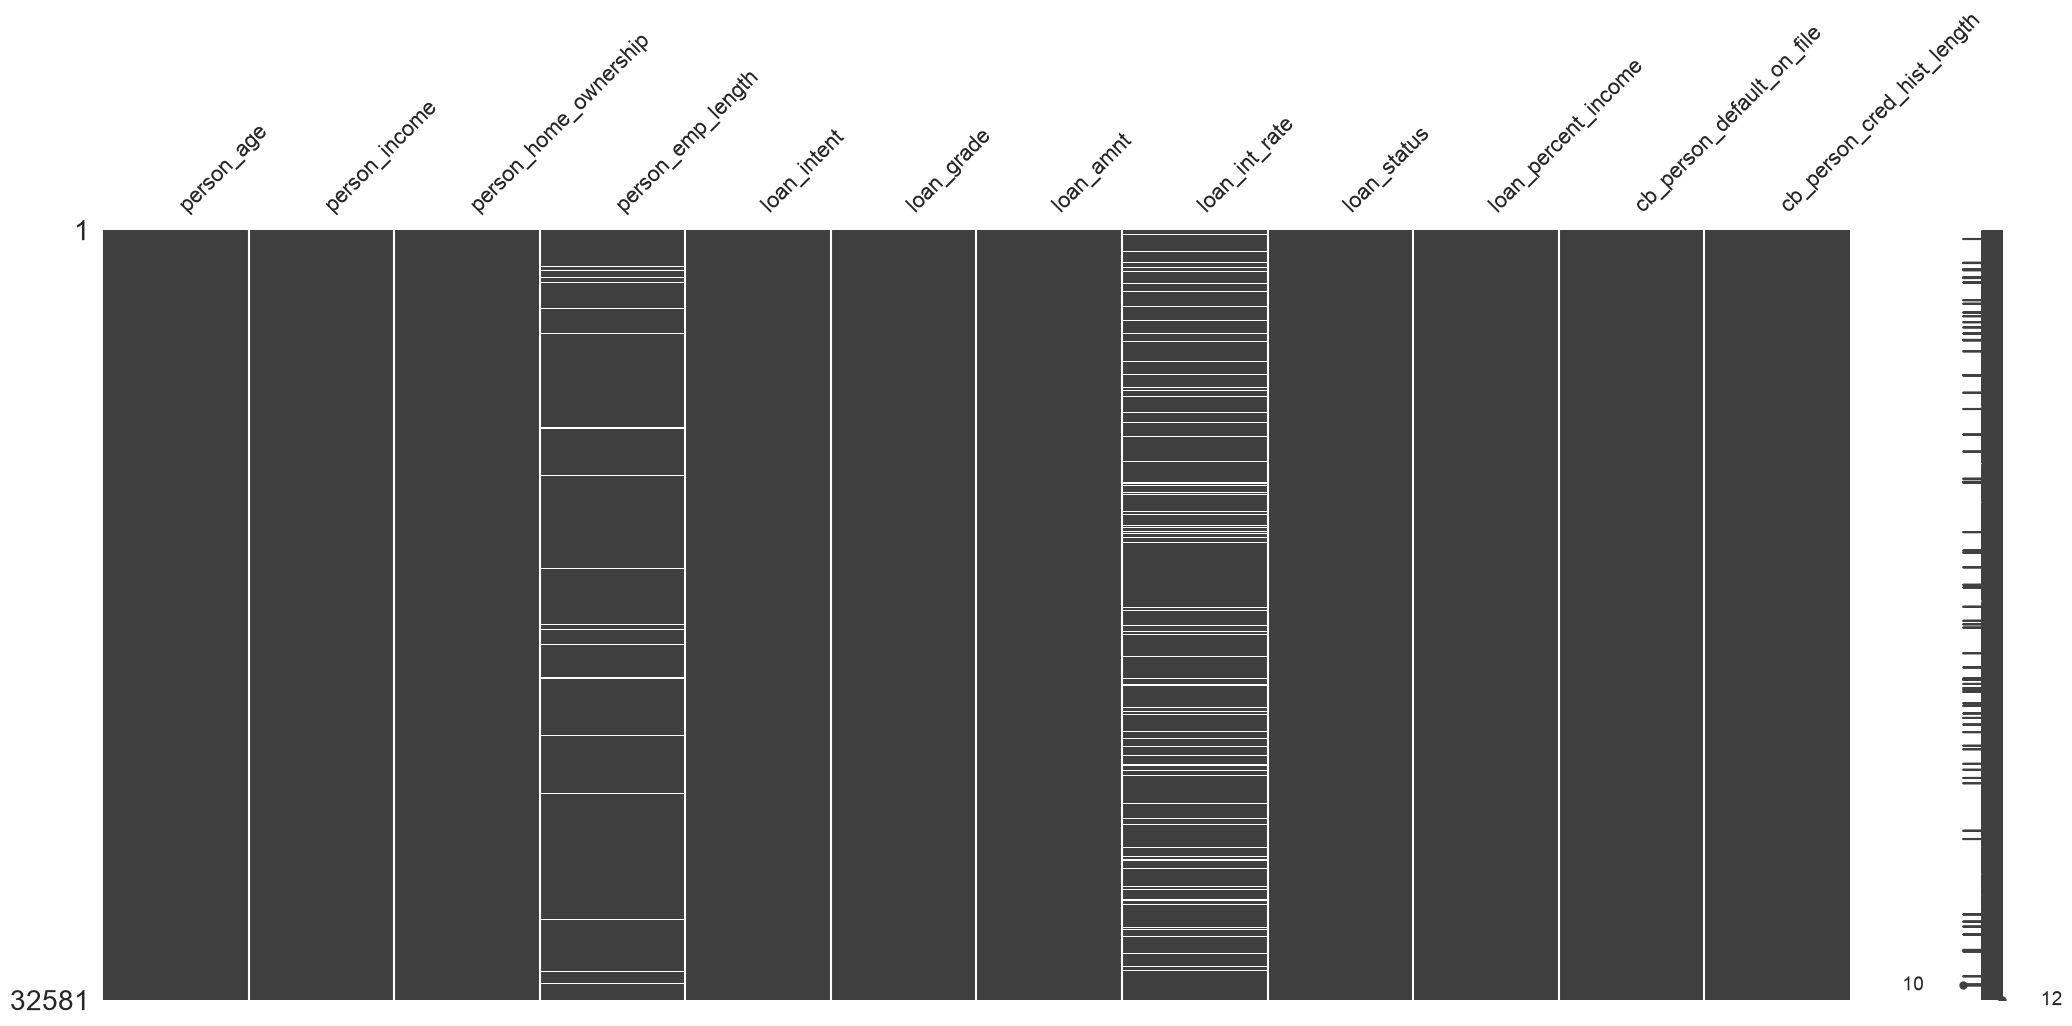

In [22]:
msno.matrix(df)
plt.show()

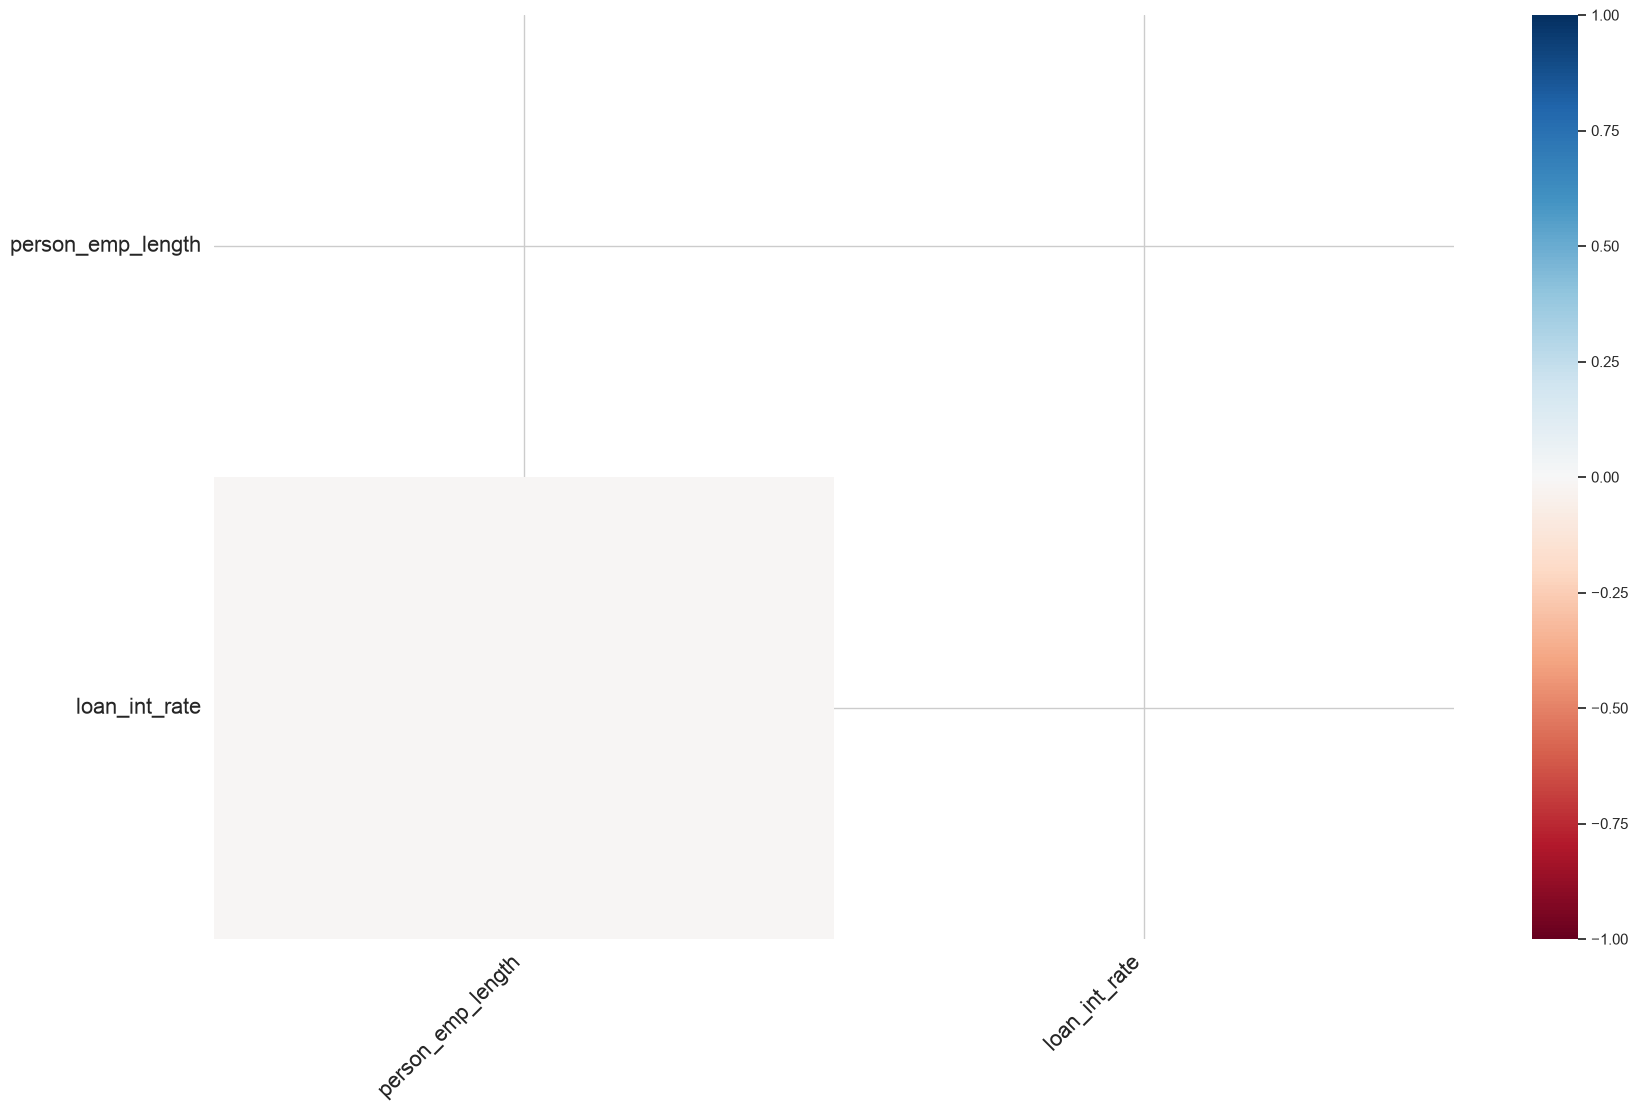

In [23]:
msno.heatmap(df)
plt.show()

In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 165


In [25]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

In [26]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/1325783283.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


### Data Quality Summary

- Missing values exist in `person_emp_length` and `loan_int_rate`.
- 165 duplicate rows were found.
- Data types are appropriate for analysis.
- Categorical columns contain consistent category names.

In [27]:
df_clean = df.copy()

In [28]:
df_clean.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [29]:
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

In [30]:
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

In [31]:
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [32]:
duplicates = df_clean.duplicated().sum()
print(f"Duplicate Rows Before: {duplicates}")

Duplicate Rows Before: 165


In [33]:
df_clean = df_clean.drop_duplicates()

In [34]:
print(df_clean.duplicated().sum())

0


In [35]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  str    
 3   person_emp_length           32416 non-null  float64
 4   loan_intent                 32416 non-null  str    
 5   loan_grade                  32416 non-null  str    
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               32416 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  str    
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


In [36]:
df_clean["person_age"].describe()

count    32416.000000
mean        27.747008
std          6.354100
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [37]:
df_clean[df_clean["person_age"] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [38]:
df_clean["person_emp_length"].describe()

count    32416.000000
mean         4.768880
std          4.090411
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [39]:
df_clean[df_clean["person_emp_length"] > 60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [40]:
df_clean = df_clean[df_clean["person_age"] <= 100]

In [41]:
print("Original Shape :", df.shape)
print("Cleaned Shape  :", df_clean.shape)

Original Shape : (32581, 12)
Cleaned Shape  : (32411, 12)


In [42]:
df_clean.to_csv(
    "../data/processed/credit_risk_cleaned.csv",
    index=False
)

In [43]:
import os

os.path.exists("../data/processed/credit_risk_cleaned.csv")

True

### Data Cleaning Summary

The dataset was cleaned by:

- Filling missing values in `person_emp_length` using the median.
- Filling missing values in `loan_int_rate` using the median.
- Removing duplicate records (if any).
- Removing unrealistic age values (>100 years).
- Removing unrealistic employment lengths (>60 years).
- Saving the cleaned dataset for further exploratory analysis.


In [44]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [45]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"\n===== {col} =====")
    print(df_clean[col].value_counts())


===== person_home_ownership =====
person_home_ownership
RENT        16375
MORTGAGE    13367
OWN          2563
OTHER         106
Name: count, dtype: int64

===== loan_intent =====
loan_intent
EDUCATION            6409
MEDICAL              6042
VENTURE              5680
PERSONAL             5497
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

===== loan_grade =====
loan_grade
A    10703
B    10384
C     6436
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

===== cb_person_default_on_file =====
cb_person_default_on_file
N    26681
Y     5730
Name: count, dtype: int64


/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/1049972830.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:


In [46]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32411.0,27.730369,6.210448,20.00,23.00,26.00,30.00,94.00
person_income,32411.0,65897.955170,52520.934765,4000.00,38500.00,55000.00,79200.00,2039784.00
person_emp_length,32411.0,4.768720,4.090478,0.00,2.00,4.00,7.00,123.00
loan_amnt,32411.0,9593.591682,6322.529723,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32411.0,11.014528,3.083234,5.42,8.49,10.99,13.11,23.22
loan_status,32411.0,0.218722,0.413386,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32411.0,0.170259,0.106808,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32411.0,5.811052,4.057816,2.00,3.00,4.00,8.00,30.00


In [47]:
df_clean["loan_status"].value_counts()

loan_status
0    25322
1     7089
Name: count, dtype: int64

In [48]:
(
    df_clean["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status
0    78.13
1    21.87
Name: proportion, dtype: float64

In [49]:
df_clean["income_group"] = pd.qcut(
    df_clean["person_income"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [50]:
df_clean["income_group"].value_counts()

income_group
Medium       8188
Low          8104
Very High    8100
High         8019
Name: count, dtype: int64

In [51]:
df_clean["age_group"] = pd.cut(
    df_clean["person_age"],
    bins=[18, 25, 35, 45, 60, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [52]:
df_clean["age_group"].value_counts()

age_group
18-25    15245
26-35    13711
36-45     2809
46-60      581
60+         65
Name: count, dtype: int64

In [53]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_group,age_group
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,High,18-25
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Low,18-25
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Low,18-25
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,High,18-25
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Medium,18-25


In [54]:
df_clean.to_csv(
    "../data/processed/credit_risk_cleaned.csv",
    index=False
)

### Feature Preparation Summary

The cleaned dataset was further prepared for exploratory analysis by:

- Validating categorical feature consistency.
- Reviewing numerical feature distributions.
- Examining the target class distribution.
- Creating income-based customer groups using quartiles.
- Creating age groups for demographic analysis.
- Saving the updated dataset for visualization.

# 6. Univariate Analysis

This section explores the distribution of individual variables to understand their characteristics, identify patterns, and detect potential outliers.

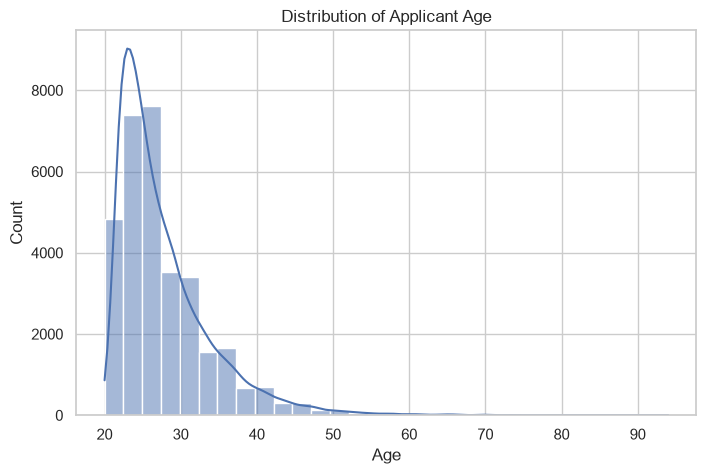

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["person_age"], bins=30, kde=True)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()


### Observation

Most applicants are between 20 and 30 years old, indicating that the dataset primarily consists of young borrowers.

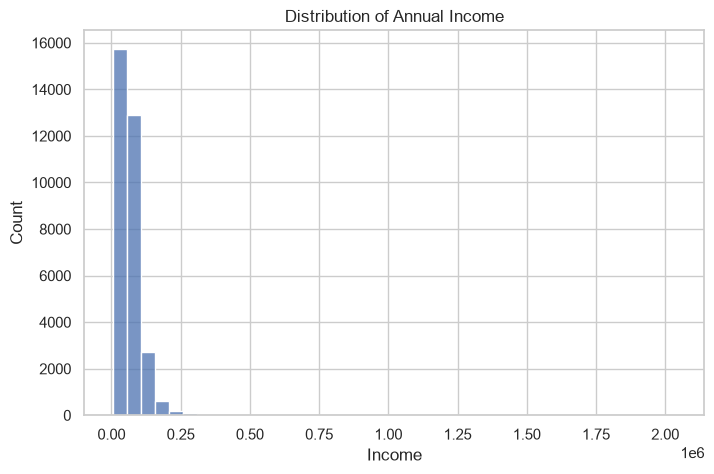

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["person_income"], bins=40)

plt.title("Distribution of Annual Income")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

Income is highly right-skewed, with most applicants earning lower to middle incomes while a small number earn substantially higher incomes.

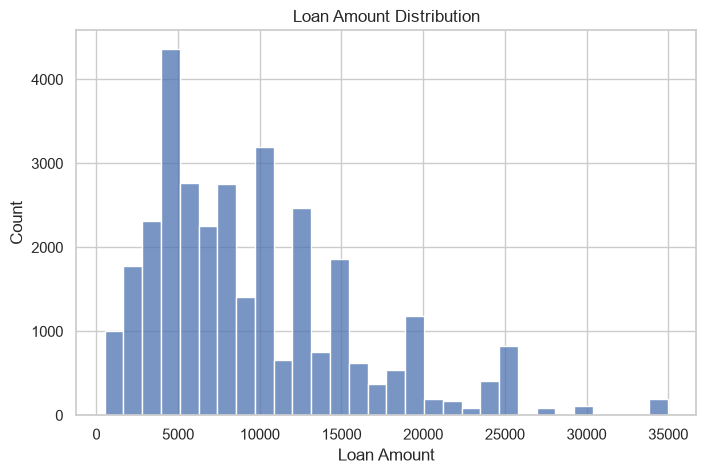

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["loan_amnt"], bins=30)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")

plt.show()

Most requested loans are relatively small, while only a few applicants request large loan amounts.


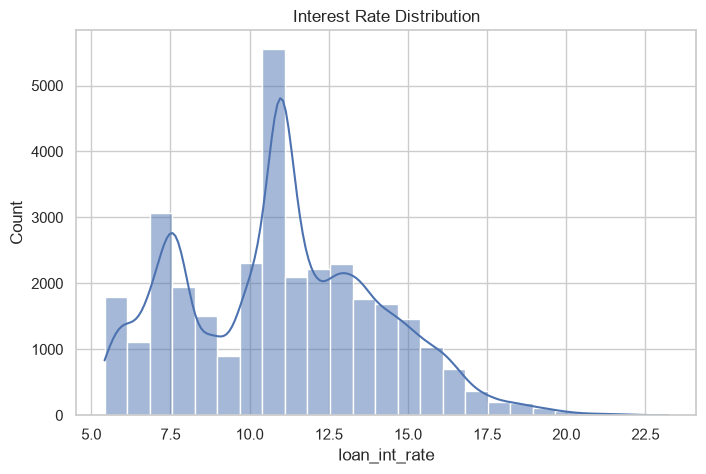

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["loan_int_rate"], bins=25, kde=True)

plt.title("Interest Rate Distribution")

plt.show()

Interest rates are concentrated within a moderate range, with fewer loans issued at extremely high interest rates.

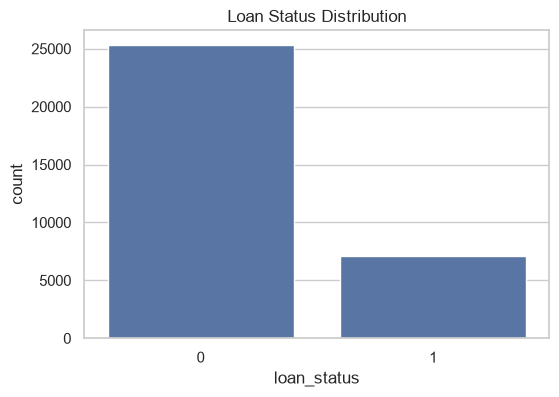

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_status", data=df_clean)

plt.title("Loan Status Distribution")

plt.show()

The majority of loans are non-defaults, indicating that the dataset is moderately imbalanced.

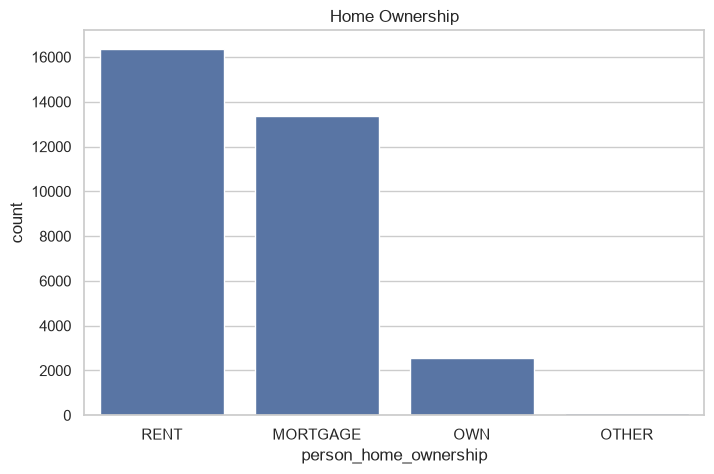

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="person_home_ownership",
    order=df_clean["person_home_ownership"].value_counts().index
)

plt.title("Home Ownership")

plt.show()

Most applicants either rent or have a mortgage, while relatively few own their homes outright.

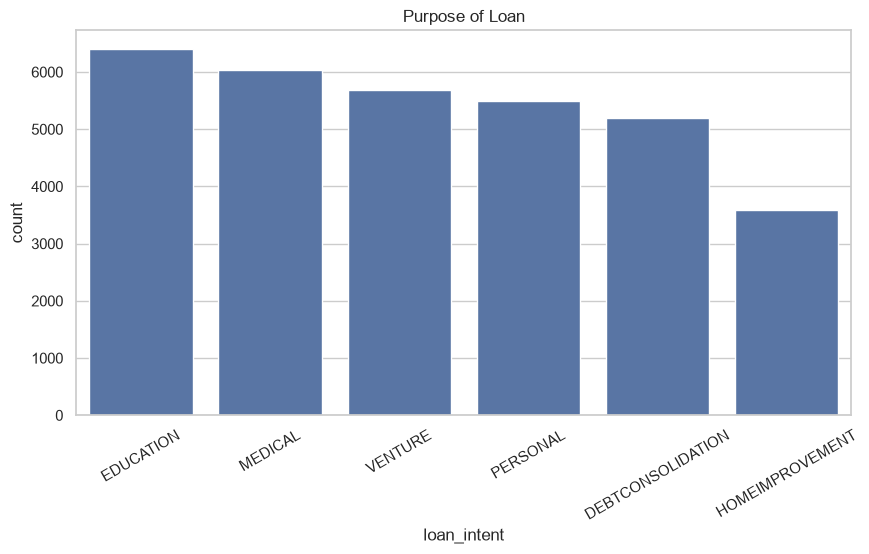

In [61]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="loan_intent",
    order=df_clean["loan_intent"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Purpose of Loan")

plt.show()

Personal, medical, and education loans are the most common borrowing purposes.

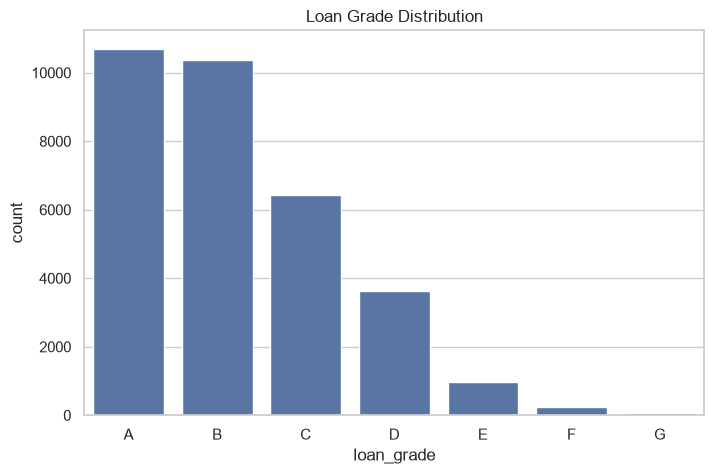

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="loan_grade",
    order=sorted(df_clean["loan_grade"].unique())
)

plt.title("Loan Grade Distribution")

plt.show()

Most approved loans fall within the middle credit grades, while very high- and very low-grade loans are less frequent.

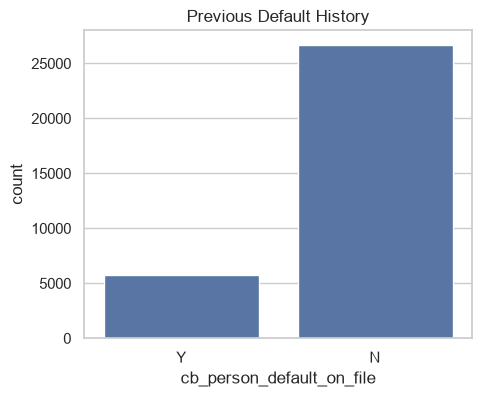

In [63]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df_clean,
    x="cb_person_default_on_file"
)

plt.title("Previous Default History")

plt.show()

A large majority of applicants have no previous default recorded, suggesting that prior defaults are relatively uncommon.

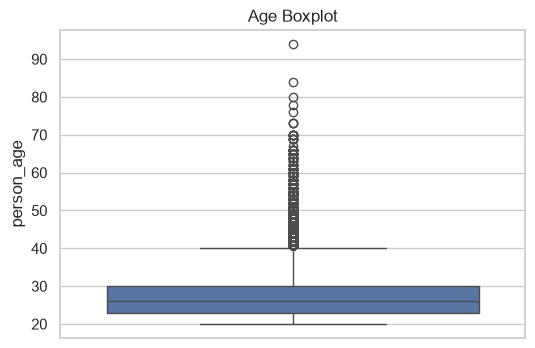

In [64]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df_clean["person_age"])

plt.title("Age Boxplot")

plt.show()

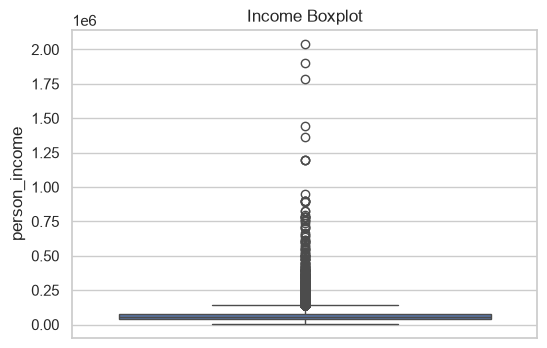

In [65]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df_clean["person_income"])

plt.title("Income Boxplot")

plt.show()

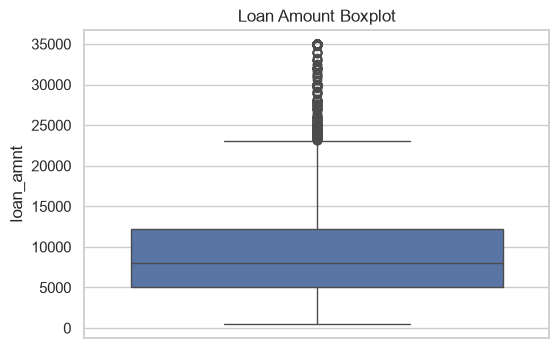

In [66]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df_clean["loan_amnt"])

plt.title("Loan Amount Boxplot")

plt.show()

## Univariate Analysis Summary

Key findings from the univariate analysis include:

- The applicant population is predominantly young adults.
- Income distribution is positively skewed with several high-income outliers.
- Loan amounts are concentrated in lower ranges.
- Most applicants have not previously defaulted.
- Renting is the most common home ownership status.
- Personal, education, and medical loans represent the largest share of loan purposes.
- Several numerical variables exhibit outliers, particularly income and loan amount.

In [67]:
plt.savefig("../reports/figures/age_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# 7. Bivariate Analysis

This section explores relationships between two variables, with a primary focus on identifying factors associated with loan default (`loan_status`).

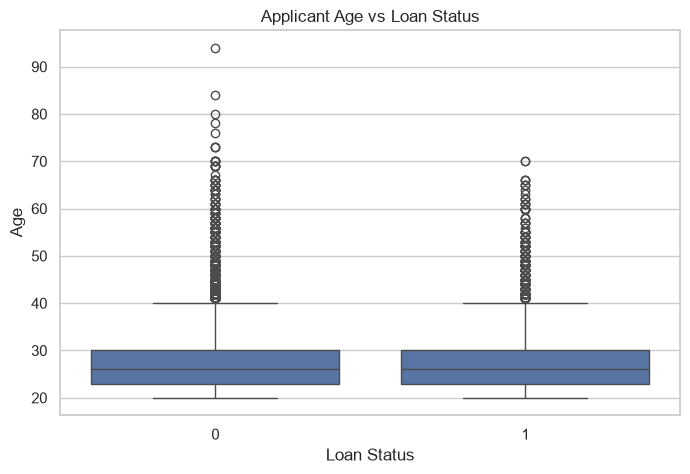

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="person_age",
    data=df_clean
)

plt.title("Applicant Age vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Age")

plt.show()

Applicants who defaulted and those who did not have similar age distributions, suggesting that age alone may not strongly influence loan default.

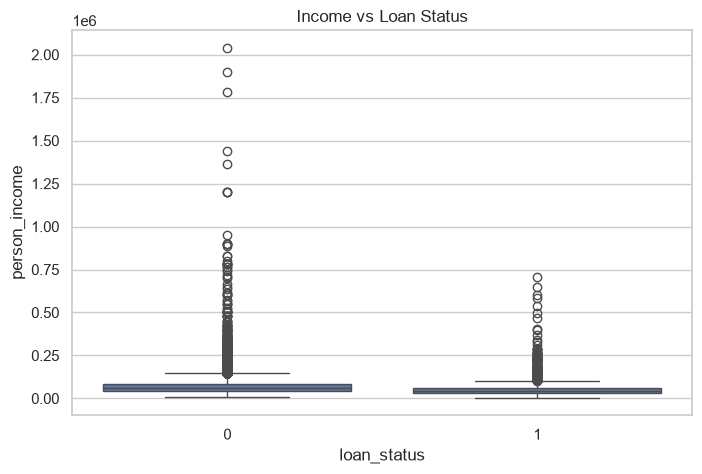

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="person_income",
    data=df_clean
)

plt.title("Income vs Loan Status")

plt.show()

Applicants with lower incomes appear to have a higher tendency to default compared to higher-income borrowers.

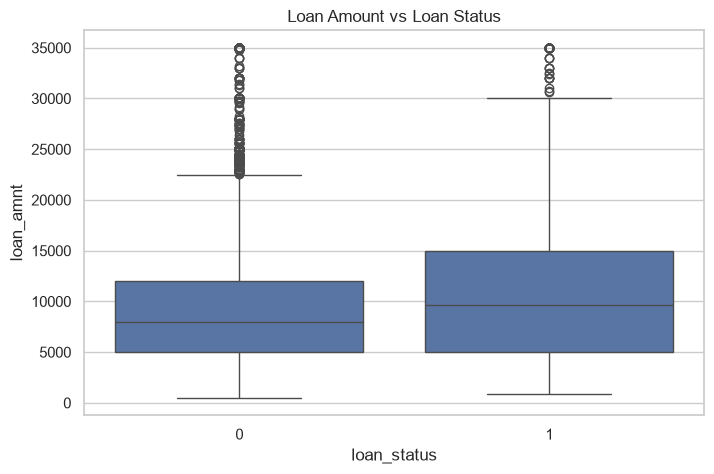

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="loan_amnt",
    data=df_clean
)

plt.title("Loan Amount vs Loan Status")

plt.show()

Higher loan amounts are associated with a greater likelihood of loan default.


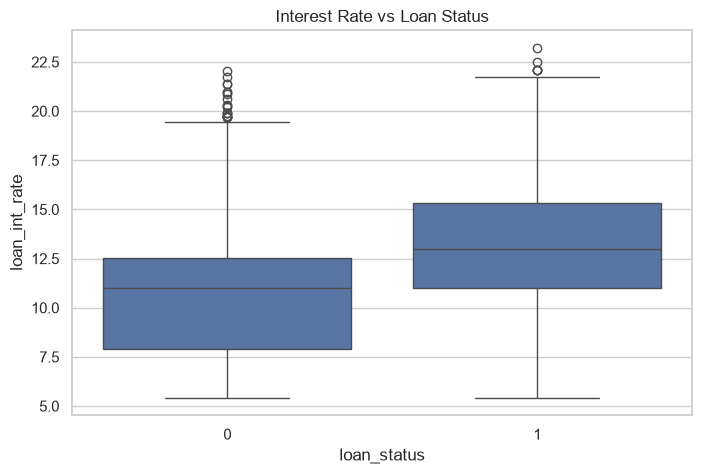

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="loan_int_rate",
    data=df_clean
)

plt.title("Interest Rate vs Loan Status")

plt.show()

Loans with higher interest rates tend to show a greater proportion of defaults.

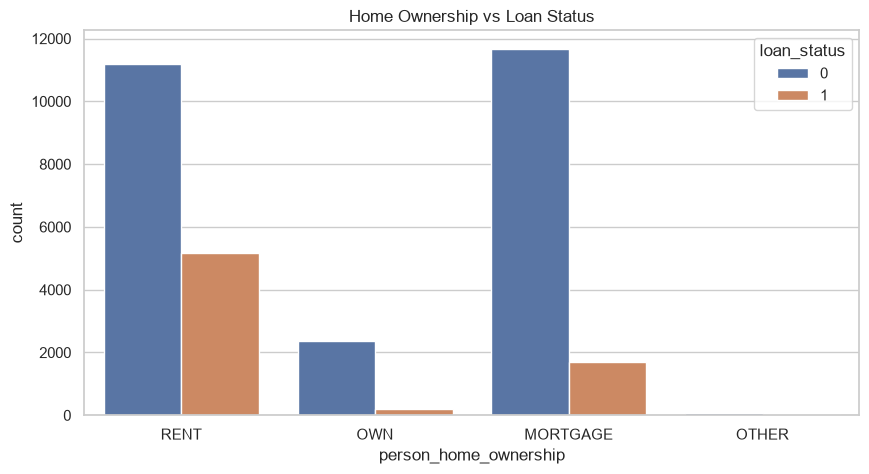

In [72]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="person_home_ownership",
    hue="loan_status"
)

plt.title("Home Ownership vs Loan Status")

plt.show()

Loan outcomes vary across home ownership categories, with renters generally contributing the largest number of defaults due to their higher representation in the dataset.

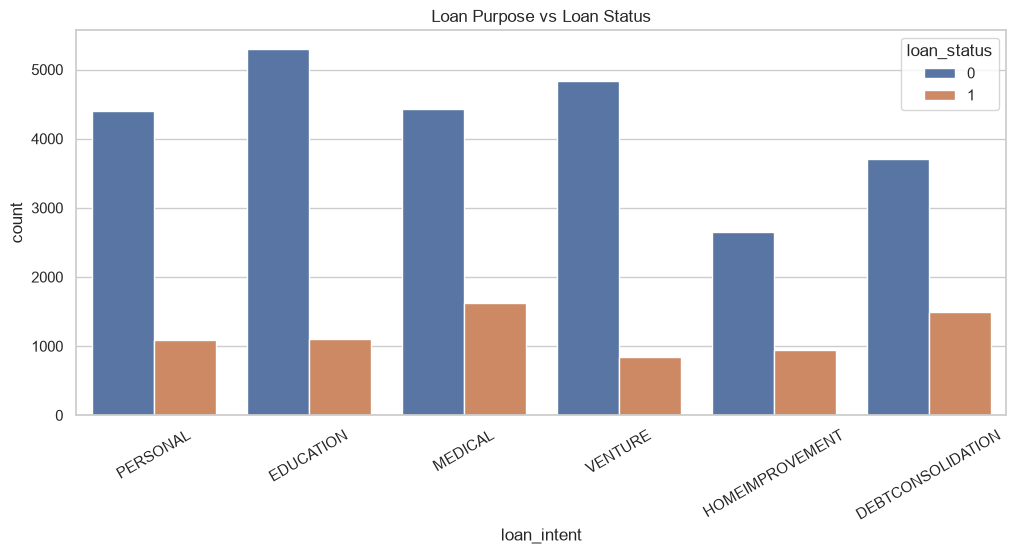

In [73]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df_clean,
    x="loan_intent",
    hue="loan_status"
)

plt.xticks(rotation=30)

plt.title("Loan Purpose vs Loan Status")

plt.show()

Certain loan purposes, such as personal and medical loans, appear to have more defaults than others.

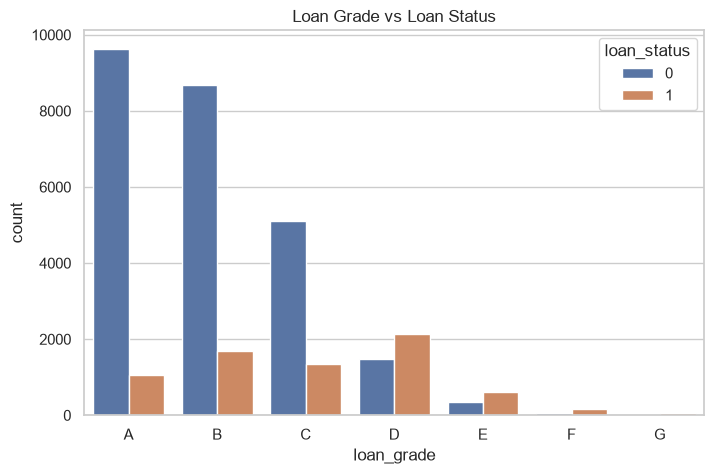

In [74]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="loan_grade",
    hue="loan_status",
    order=sorted(df_clean["loan_grade"].unique())
)

plt.title("Loan Grade vs Loan Status")

plt.show()

Lower credit grades generally exhibit a higher proportion of loan defaults compared to higher credit grades.

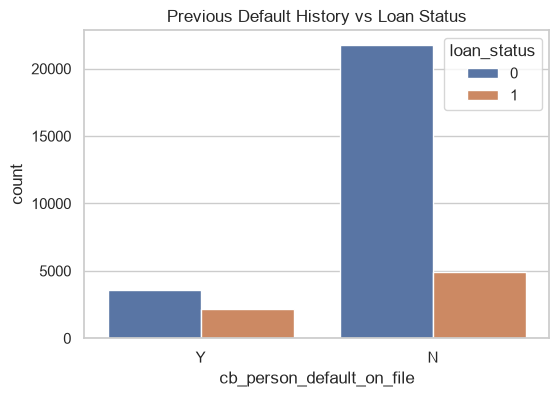

In [75]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="cb_person_default_on_file",
    hue="loan_status"
)

plt.title("Previous Default History vs Loan Status")

plt.show()

Applicants with a previous default history appear more likely to default again than those without prior defaults.

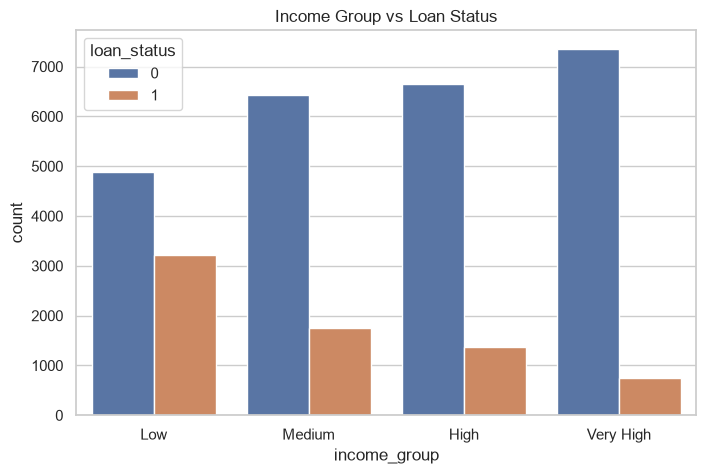

In [76]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="income_group",
    hue="loan_status"
)

plt.title("Income Group vs Loan Status")

plt.show()

Lower income groups show a higher concentration of loan defaults compared to higher income groups.

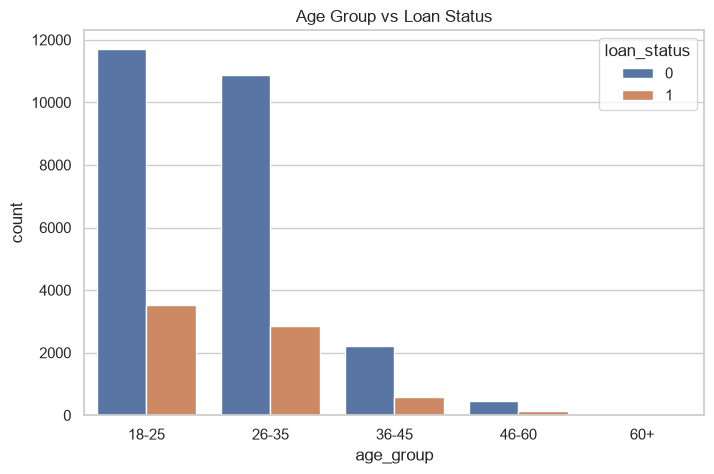

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="age_group",
    hue="loan_status"
)

plt.title("Age Group vs Loan Status")

plt.show()

## Bivariate Analysis Summary

Key observations include:

- Lower-income applicants appear to default more frequently.
- Higher loan amounts are associated with increased default risk.
- Higher interest rates correspond to higher default rates.
- Lower loan grades show a greater proportion of defaults.
- Applicants with previous defaults are more likely to default again.
- Default rates differ across loan purposes and home ownership categories.

Default patterns vary across age groups, although the younger groups account for most loan applications.

In [78]:
plt.savefig("../reports/figures/income_vs_loan_status.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# 8. Multivariate Analysis and Business Insights

This section investigates relationships among multiple variables to identify key factors influencing loan default and summarizes the findings into actionable business insights.

In [79]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

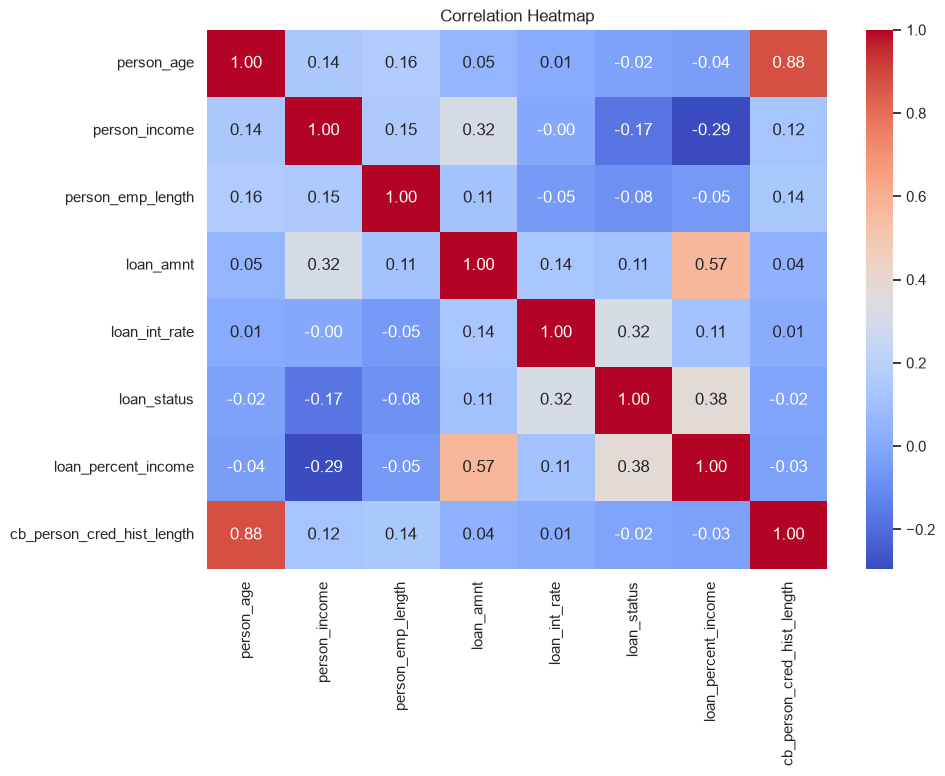

In [80]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [81]:
plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

The correlation heatmap indicates that loan amount, loan percent income, and interest rate exhibit meaningful relationships with loan status, while age shows relatively weak correlation.

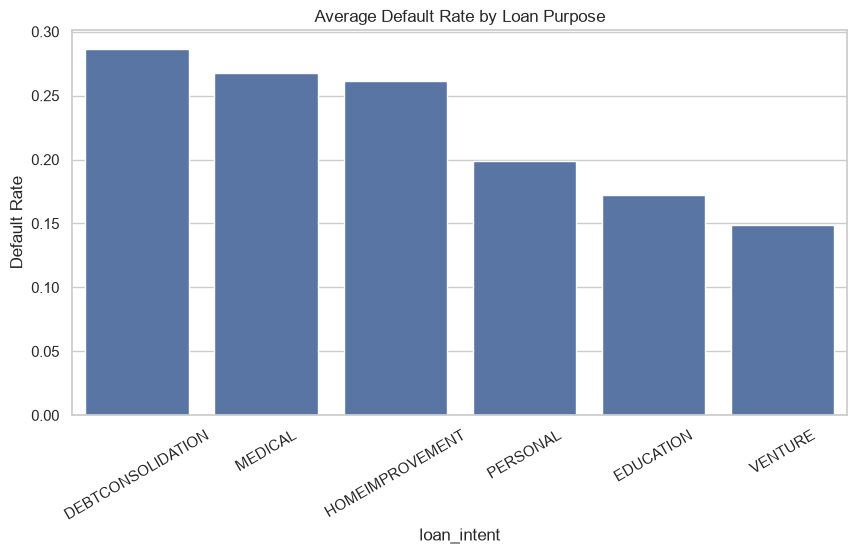

In [82]:
default_rate_intent = (
    df_clean
    .groupby("loan_intent")["loan_status"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=default_rate_intent.index,
    y=default_rate_intent.values
)

plt.xticks(rotation=30)

plt.ylabel("Default Rate")

plt.title("Average Default Rate by Loan Purpose")

plt.show()

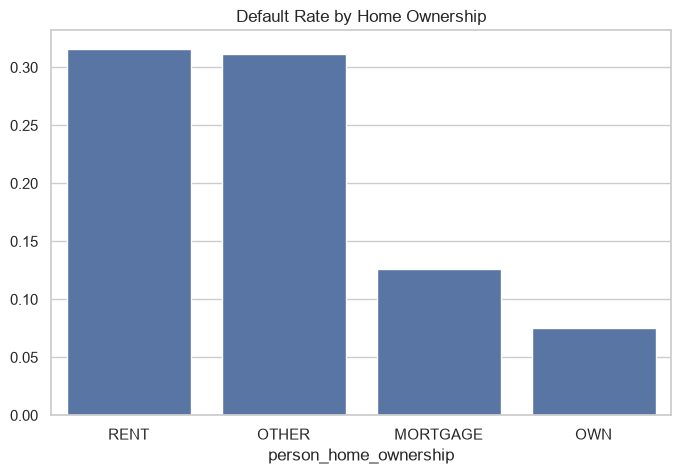

In [83]:
default_rate_home = (
    df_clean
    .groupby("person_home_ownership")["loan_status"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=default_rate_home.index,
    y=default_rate_home.values
)

plt.title("Default Rate by Home Ownership")

plt.show()

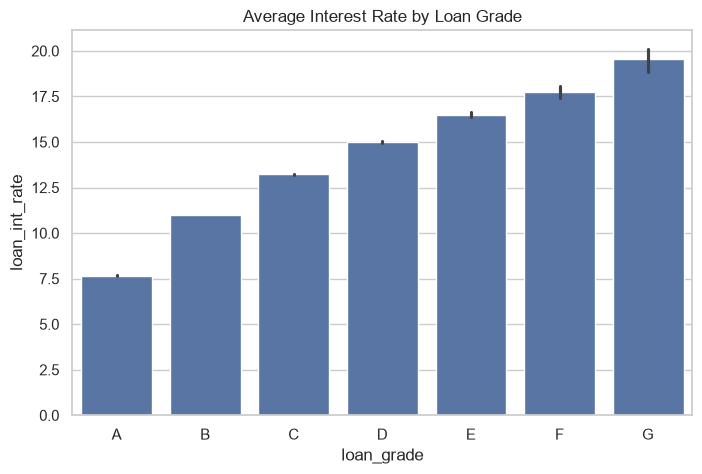

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="loan_grade",
    y="loan_int_rate",
    order=sorted(df_clean["loan_grade"].unique())
)

plt.title("Average Interest Rate by Loan Grade")

plt.show()

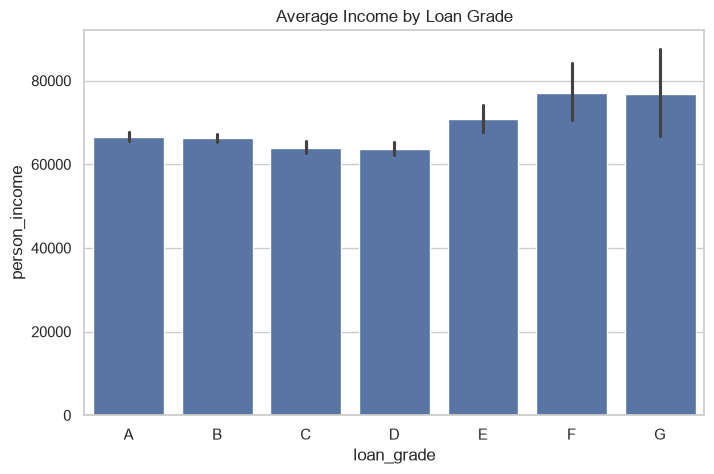

In [85]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="loan_grade",
    y="person_income",
    order=sorted(df_clean["loan_grade"].unique())
)

plt.title("Average Income by Loan Grade")

plt.show()

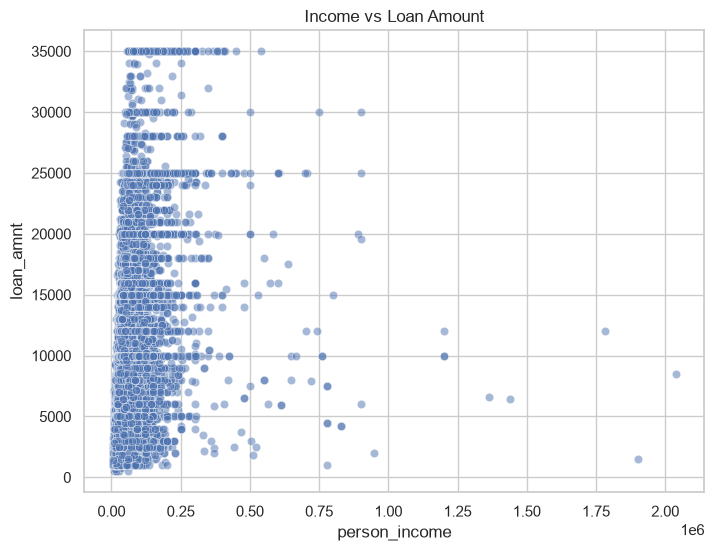

In [86]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="person_income",
    y="loan_amnt",
    alpha=0.5
)

plt.title("Income vs Loan Amount")

plt.show()

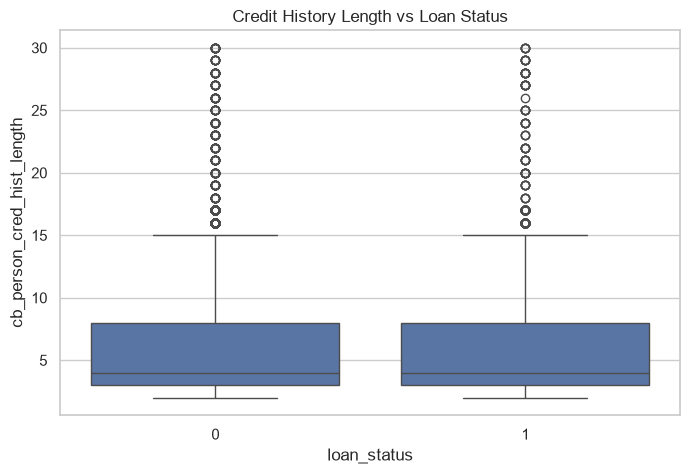

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="cb_person_cred_hist_length"
)

plt.title("Credit History Length vs Loan Status")

plt.show()

# Business Insights

### Key Findings

1. Most applicants belong to the younger working-age population.

2. Income distribution is heavily right-skewed, indicating that a small proportion of applicants earn significantly higher incomes.

3. Lower-income applicants tend to default more frequently.

4. Applicants requesting larger loan amounts exhibit higher default rates.

5. Higher interest rates are associated with an increased probability of default.

6. Previous loan default history is a strong indicator of future default.

7. Loan grade is one of the strongest predictors of repayment behavior.

8. Personal and medical loans contribute a substantial share of defaults.

9. Renters account for a larger number of loan applications and defaults compared to homeowners.

10. Credit history length appears to influence loan repayment reliability.

11. Loan percent income shows a noticeable relationship with default risk.

12. Age alone does not appear to be a strong predictor of loan default.

# Conclusion

This exploratory data analysis identified several financial and demographic factors associated with loan default.

Income level, loan amount, interest rate, previous default history, loan grade, and credit history length emerged as the most influential variables. These insights can support future predictive modeling and help financial institutions improve credit risk assessment and lending strategies.

The cleaned dataset and findings provide a strong foundation for building machine learning models such as Logistic Regression, Random Forest, or XGBoost for credit default prediction.

In [88]:
df_clean.to_csv(
    "../data/processed/credit_risk_cleaned.csv",
    index=False
)
